# ETL

In [43]:
def extract_data(path):
    print("📥 Extracting data...")
    return pd.read_csv(path)

In [44]:
import pandas as pd

def transform_data(df: pd.DataFrame):
    print("🔄 Transforming data...")

    # =========================
    # 🧹 CLEANING
    # =========================
    df.columns = df.columns.str.strip()

    # convert datetime
    df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
    df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')
    df['DOB'] = pd.to_datetime(df['DOB'], format='%m/%d/%y', errors='coerce')

    # =========================
    # 🧠 FIX AGE (IMPORTANT)
    # =========================
    today = pd.Timestamp.today()

    df['Age'] = ((today - df['DOB']).dt.days // 365)

    # handle missing
    df['Salary'] = df['Salary'].fillna(df['Salary'].median())
    df['Age'] = df['Age'].fillna(df['Age'].median())

    # standardize gender
    df['Sex'] = df['Sex'].replace({'M': 'Male', 'F': 'Female'})

    # =========================
    # 🧠 FEATURE ENGINEERING
    # =========================
    df['tenure_days'] = (today - df['DateofHire']).dt.days
    df['tenure_years'] = df['tenure_days'] / 365

    df['is_attrition'] = df['DateofTermination'].notna()
    df['is_active'] = df['DateofTermination'].isna()

    df['age_group'] = pd.cut(
        df['Age'],
        bins=[20, 30, 40, 50, 60, 70],
        labels=['20-30', '30-40', '40-50', '50-60', '60+']
    )

    # =========================
    # 🧪 VALIDATION (SAFE)
    # =========================
    df['Salary'] = df['Salary'].clip(lower=0)
    df['Age'] = df['Age'].clip(lower=18, upper=70)

    # =========================
    # 🧱 DIMENSION TABLES
    # =========================

    # DIM DEPARTMENT
    dim_department = df[['Department']].drop_duplicates().reset_index(drop=True)
    dim_department['department_id'] = dim_department.index + 1
    df = df.merge(dim_department, on='Department', how='left')

    # DIM POSITION
    dim_position = df[['Position']].drop_duplicates().reset_index(drop=True)
    dim_position['position_id'] = dim_position.index + 1
    df = df.merge(dim_position, on='Position', how='left')

    # =========================
    # DIM SALARY
    # =========================
    dim_salary = df[['Salary']].copy()

    # handle missing dulu
    dim_salary['Salary'] = dim_salary['Salary'].fillna(dim_salary['Salary'].median())

    # drop duplicate
    dim_salary = dim_salary.drop_duplicates().reset_index(drop=True)

    # kasih ID
    dim_salary['salary_id'] = dim_salary.index + 1

    # SAFE BINNING
    if dim_salary['Salary'].nunique() >= 3:
        dim_salary['salary_level'] = pd.qcut(
            dim_salary['Salary'],
            3,
            labels=['Low', 'Medium', 'High'],
            duplicates='drop'
        )
    else:
        dim_salary['salary_level'] = 'Medium'

    # MERGE (IMPORTANT)
    df = df.merge(dim_salary, on='Salary', how='left')

    # =========================
    # DIM MANAGER
    # =========================
    dim_manager = df[['ManagerName']].drop_duplicates().reset_index(drop=True)
    dim_manager['manager_id'] = dim_manager.index + 1

    df = df.merge(dim_manager, on='ManagerName', how='left')

    # =========================
    # DIM RECRUITMENT
    # =========================
    dim_recruitment = df[['RecruitmentSource']].drop_duplicates().reset_index(drop=True)
    dim_recruitment['recruitment_id'] = dim_recruitment.index + 1
    df = df.merge(dim_recruitment, on='RecruitmentSource', how='left')

    # =========================
    # DIM RACE
    # =========================
    dim_race = df[['RaceDesc']].drop_duplicates().reset_index(drop=True)
    dim_race['race_id'] = dim_race.index + 1

    df = df.merge(dim_race, on='RaceDesc', how='left')

    # =========================
    # 🟦 FACT TABLE
    # =========================
    fact_employees = df[[
        'EmpID',
        'Employee_Name',
        'Sex',
        'Age',
        'age_group',
        'tenure_years',
        'is_attrition',
        'is_active',
        'DateofHire',
        'DateofTermination',
        'department_id',
        'position_id',
        'salary_id',
        'manager_id',
        'recruitment_id',
        'race_id'
    ]].copy()

    fact_employees.columns = [
        'emp_id', 'name', 'gender', 'age',
        'age_group', 'tenure_years',
        'is_attrition', 'is_active',
        'hire_date', 'termination_date',
        'department_id', 'position_id',
        'salary_id','manager_id','recruitment_id', 'race_id'
    ]

    # =========================
    # 🟨 OTHER DIM
    # =========================

    # DIM PERFORMANCE
    dim_performance = df[['EmpID', 'PerformanceScore']].copy()
    dim_performance.columns = ['emp_id', 'performance_score']

    # DIM ABSENCE
    dim_absence = df[['EmpID', 'Absences']].copy()
    dim_absence.columns = ['emp_id', 'absences']


    # =========================
    # 📊 ANALYTICS TABLE
    # =========================
    agg_department = df.groupby('Department').agg({
        'Salary': 'mean',
        'EmpID': 'count',
        'is_attrition': 'mean'
    }).reset_index()

    agg_department.columns = [
        'department', 'avg_salary', 'total_employee', 'attrition_rate'
    ]

    # =========================
    # 📦 RETURN
    # =========================
    return {
        "fact_employees": fact_employees,
        "dim_department": dim_department,
        "dim_position": dim_position,
        "dim_salary": dim_salary,
        "dim_performance": dim_performance,
        "dim_absence": dim_absence,
        "agg_department": agg_department,
        "dim_manager": dim_manager,
        "dim_recruitment": dim_recruitment,
        "dim_race": dim_race
    }

In [45]:
import os

def load_data(tables: dict):
    print("💾 Loading data...")

    os.makedirs("data/processed", exist_ok=True)
    os.makedirs("data/analytics", exist_ok=True)

    for name, df in tables.items():
        if "agg" in name:
            path = f"data/analytics/{name}.csv"
        else:
            path = f"data/processed/{name}.csv"

        df.to_csv(path, index=False)
        print(f"✅ Saved: {path}")

In [46]:
"""from extract import extract_data
from transform import transform_data
from load import load_data"""

def run_pipeline():
    print("🚀 HR ETL PIPELINE")
    print("="*40)

    df = extract_data("/content/HRDataset_v14.csv")  # fix path juga
    tables = transform_data(df)
    load_data(tables)

    print("🎉 DONE!")

run_pipeline()

🚀 HR ETL PIPELINE
📥 Extracting data...
🔄 Transforming data...
💾 Loading data...
✅ Saved: data/processed/fact_employees.csv
✅ Saved: data/processed/dim_department.csv
✅ Saved: data/processed/dim_position.csv
✅ Saved: data/processed/dim_salary.csv
✅ Saved: data/processed/dim_performance.csv
✅ Saved: data/processed/dim_absence.csv
✅ Saved: data/analytics/agg_department.csv
✅ Saved: data/processed/dim_manager.csv
✅ Saved: data/processed/dim_recruitment.csv
✅ Saved: data/processed/dim_race.csv
🎉 DONE!


#Insight

In [47]:
fact = pd.read_csv("data/processed/fact_employees.csv")
manager = pd.read_csv("data/processed/dim_manager.csv")
performance = pd.read_csv("data/processed/dim_performance.csv")
recruitment = pd.read_csv("data/processed/dim_recruitment.csv")

df_analysis = fact \
    .merge(manager, on='manager_id', how='left') \
    .merge(performance, on='emp_id', how='left') \
    .merge(recruitment, on='recruitment_id', how='left')

In [48]:
#Is there any relationship between who a person works for and their performance score?

df.groupby('ManagerName')['performance_score'] \
    .value_counts(normalize=True)

ManagerName         performance_score
Alex Sweetwater     Fully Meets          0.666667
                    Exceeds              0.222222
                    Needs Improvement    0.111111
Amy Dunn            Fully Meets          0.714286
                    Exceeds              0.142857
                    PIP                  0.095238
                    Needs Improvement    0.047619
Board of Directors  Fully Meets          1.000000
Brandon R. LeBlanc  Fully Meets          1.000000
Brannon Miller      Fully Meets          0.454545
                    Exceeds              0.318182
                    PIP                  0.181818
                    Needs Improvement    0.045455
Brian Champaigne    Fully Meets          1.000000
David Stanley       Fully Meets          0.904762
                    Exceeds              0.047619
                    Needs Improvement    0.047619
Debra Houlihan      Fully Meets          0.666667
                    Needs Improvement    0.333333
Elijiah Gray        Fully Meets          0.818182
                    Exceeds              0.090909
                    Needs Improvement    0.090909
Eric Dougall        Fully Meets          0.750000
                    Exceeds              0.250000
Janet King          Fully Meets          0.684211
                    Exceeds              0.210526
                    Needs Improvement    0.105263
Jennifer Zamora     Fully Meets          0.571429
                    Exceeds              0.285714
                    Needs Improvement    0.142857
John Smith          Fully Meets          0.857143
                    PIP                  0.142857
Kelley Spirea       Fully Meets          0.818182
                    Exceeds              0.136364
                    Needs Improvement    0.045455
Ketsia Liebig       Fully Meets          0.857143
                    Exceeds              0.095238
                    Needs Improvement    0.047619
Kissy Sullivan      Fully Meets          0.818182
                    Exceeds              0.090909
                    Needs Improvement    0.045455
                    PIP                  0.045455
Lynn Daneault       Fully Meets          0.692308
                    Exceeds              0.153846
                    PIP                  0.153846
Michael Albert      Fully Meets          0.727273
                    Needs Improvement    0.136364
                    Exceeds              0.090909
                    PIP                  0.045455
Peter Monroe        Fully Meets          0.928571
                    PIP                  0.071429
Simon Roup          Fully Meets          0.882353
                    Exceeds              0.117647
Webster Butler      Fully Meets          0.809524
                    Exceeds              0.095238
                    Needs Improvement    0.095238
Name: proportion, dtype: float64

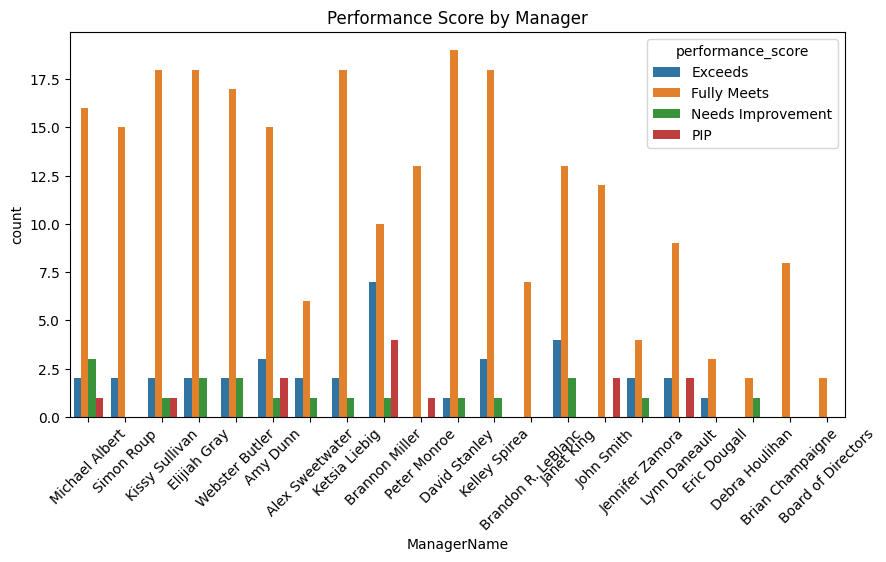

In [49]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_analysis, x='ManagerName', hue='performance_score')

plt.xticks(rotation=45)
plt.title('Performance Score by Manager')
plt.show()

In [50]:
#What is the overall diversity profile of the organization?

# Race
df_analysis = df_analysis.merge(
    pd.read_csv("data/processed/dim_race.csv"),
    on='race_id',
    how='left'
)

df_analysis['RaceDesc'].value_counts(normalize=True)

,proportion
RaceDesc,
White,0.601286
Black or African American,0.257235
Asian,0.093248
Two or more races,0.035370
American Indian or Alaska Native,0.009646
Hispanic,0.003215


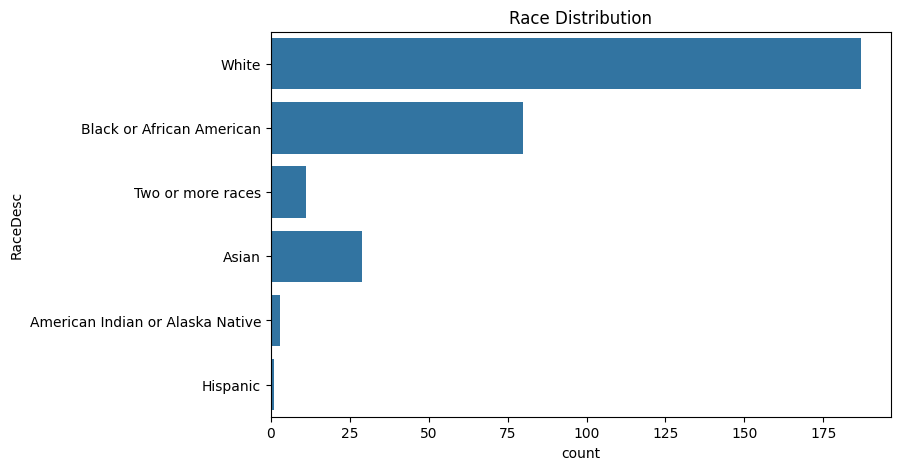

In [51]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_analysis, y='RaceDesc')

plt.title('Race Distribution')
plt.show()

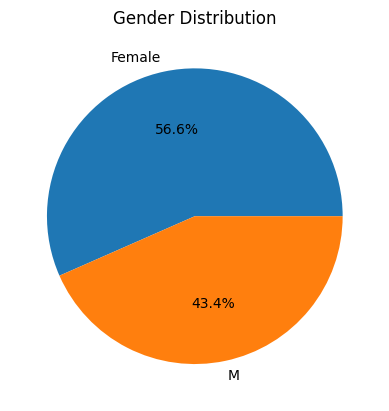

In [52]:
# Gender
df_analysis['gender'].value_counts(normalize=True)

df_analysis['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

In [54]:
#What are our best recruiting sources for diversity?

cross = pd.crosstab(
    df_analysis['RecruitmentSource'],
    df_analysis['RaceDesc'],
    normalize='index'
)
cross

RaceDesc,American Indian or Alaska Native,Asian,Black or African American,Hispanic,Two or more races,White
RecruitmentSource,,,,,,
CareerBuilder,0.000000,0.086957,0.217391,0.000000,0.000000,0.695652
Diversity Job Fair,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
Employee Referral,0.000000,0.032258,0.161290,0.000000,0.000000,0.806452
Google Search,0.020408,0.142857,0.081633,0.000000,0.040816,0.714286
Indeed,0.011494,0.114943,0.195402,0.011494,0.045977,0.620690
LinkedIn,0.013158,0.105263,0.210526,0.000000,0.052632,0.618421
On-line Web application,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Other,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Website,0.000000,0.076923,0.307692,0.000000,0.076923,0.538462


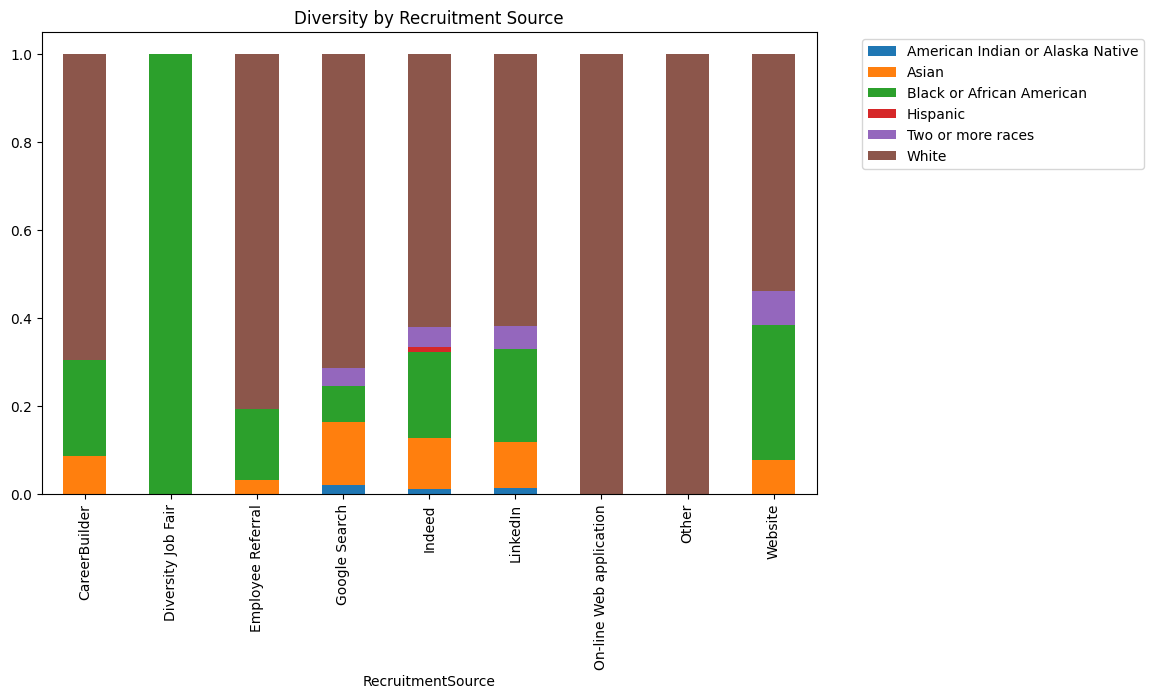

In [55]:
cross.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Diversity by Recruitment Source')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

In [57]:
#Can we predict who is going to terminate?

import pandas as pd

fact = pd.read_csv("data/processed/fact_employees.csv")
absence = pd.read_csv("data/processed/dim_absence.csv")
salary = pd.read_csv("data/processed/dim_salary.csv")

# join semua
df_analysis = fact \
    .merge(absence, on='emp_id', how='left') \
    .merge(salary, on='salary_id', how='left')

features = ['age', 'tenure_years', 'absences', 'Salary']
X = df_analysis[features]

y = df_analysis['is_attrition']

X = X.fillna(X.median())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

importance = pd.Series(model.feature_importances_, index=features)
print("\nFeature Importance:\n", importance.sort_values(ascending=False))

Accuracy: 0.7142857142857143

Classification Report:
               precision    recall  f1-score   support

       False       0.78      0.78      0.78        41
        True       0.59      0.59      0.59        22

    accuracy                           0.71        63
   macro avg       0.69      0.69      0.69        63
weighted avg       0.71      0.71      0.71        63


Confusion Matrix:
 [[32  9]
 [ 9 13]]

Feature Importance:
 tenure_years    0.474867
Salary          0.236283
absences        0.150746
age             0.138104
dtype: float64
